# EDA — Customer Personality Analysis (تجهيز للـ Unsupervised Learning)

**Data dictionary**

| Column | Description |
|---|---|
| `ID` | Unique customer identifier |
| `Year_Birth` | Customer's birth year |
| `Education` | Highest education level |
| `Marital_Status` | Marital status |
| `Income` | Annual household income |
| `Kidhome` / `Teenhome` | Number of children / teenagers at home |
| `Dt_Customer` | Enrollment date with the company |
| `Recency` | Days since the last purchase |
| `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds` | Amount spent per product category (last 2 years) |
| `NumDealsPurchases`, `NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases` | Number of purchases by channel |
| `NumWebVisitsMonth` | Website visits in the last month |
| `AcceptedCmp1`–`AcceptedCmp5` | Whether the customer accepted campaigns 1–5 |
| `Response` | Whether the customer accepted the last campaign |
| `Complain` | Whether the customer filed a complaint in the last 2 years |
| `Z_CostContact`, `Z_Revenue` | Constant values (same for every customer, not useful for analysis) |




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
df = pd.read_csv(r"C:\Users\User\Desktop\proj\1\customer_segmentation.csv")
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 1.First look at the data

In [3]:
df.shape

(2240, 29)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

### Missig and duplicates  values

In [5]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage.round(2)
})

missing_report[missing_report['Missing Values'] > 0]


,Missing Values,Percentage
Income,24,1.07


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dropna(inplace=True)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2216.0,5588.353339,3249.376275,0.0,2814.75,5458.5,8421.75,11191.0
Year_Birth,2216.0,1968.820397,11.985554,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2216.0,0.441787,0.536896,0.0,0.00,0.0,1.00,2.0
Teenhome,2216.0,0.505415,0.544181,0.0,0.00,0.0,1.00,2.0
Recency,2216.0,49.012635,28.948352,0.0,24.00,49.0,74.00,99.0
MntWines,2216.0,305.091606,337.327920,0.0,24.00,174.5,505.00,1493.0
MntFruits,2216.0,26.356047,39.793917,0.0,2.00,8.0,33.00,199.0
MntMeatProducts,2216.0,166.995939,224.283273,0.0,16.00,68.0,232.25,1725.0
MntFishProducts,2216.0,37.637635,54.752082,0.0,3.00,12.0,50.00,259.0




- `ID`drop 
- `Z_CostContact` , `Z_Revenue` Their value is fixed for all customers
- `Dt_Customer` convert to datetime 

In [9]:
constant_columns = df.columns[df.nunique() <= 1]
constant_columns


Index(['Z_CostContact', 'Z_Revenue'], dtype='object')

In [10]:
df.drop(columns=['ID'], inplace=True)
df.drop(columns=list(constant_columns), inplace=True)
df.shape


(2216, 26)

In [11]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
df["Dt_Customer_day"]   = df["Dt_Customer"].dt.day
df["Dt_Customer_month"] = df["Dt_Customer"].dt.month
df["Dt_Customer_year"]  = df["Dt_Customer"].dt.year


## 3. (Categorical columns )

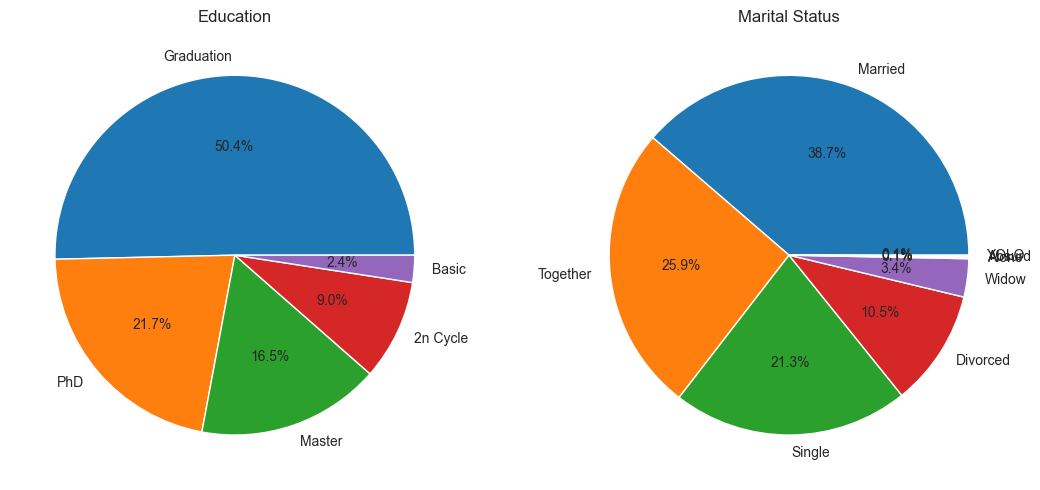

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
df['Education'].value_counts().plot.pie(autopct='%.1f%%', ax=axes[0])
axes[0].set_ylabel(''); axes[0].set_title('Education')
df['Marital_Status'].value_counts().plot.pie(autopct='%.1f%%', ax=axes[1])
axes[1].set_ylabel(''); axes[1].set_title('Marital Status')
plt.tight_layout()
plt.show()


In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print('Numeric columns:', numeric_cols)
print('\n Categorical columns:', categorical_cols)


Numeric columns: ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Dt_Customer_day', 'Dt_Customer_month', 'Dt_Customer_year']

 Categorical columns: ['Education', 'Marital_Status']


##  (Feature Engineering)



### 4.1 `Acceptany` — إجمالي استجابة العميل للحملات

عندنا 6 أعمدة binary منفصلة (`AcceptedCmp1..5` و `Response`). المشكلة إن كل عمود منهم **نادر جدًا** (نسبة الـ 1 فيه قليلة)، فلو سبناهم منفصلين هيبقى تأثيرهم على مسافة الكلسترة ضعيف جدًا وهيتوهوا وسط باقي الأعمدة. الحل إننا نجمعهم في عمود واحد يعبّر عن "مدى استجابة العميل للتسويق" ككل.

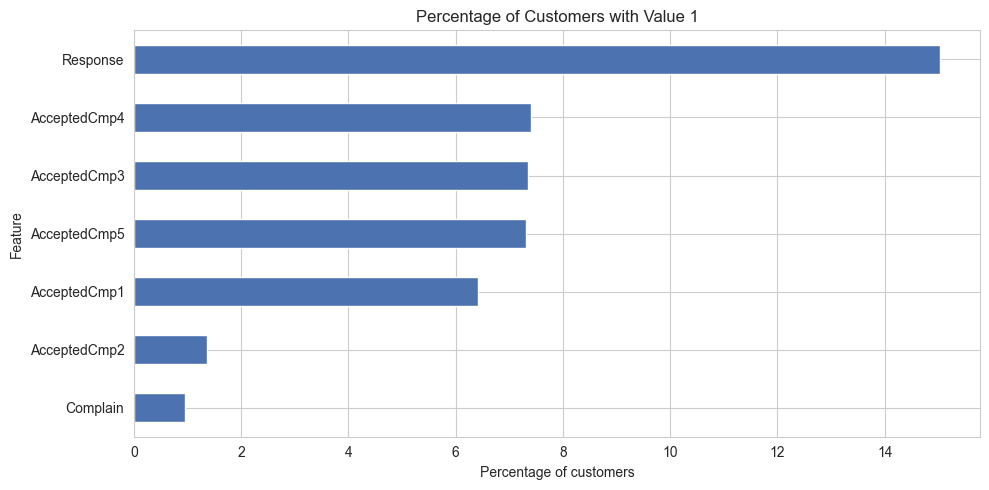

In [16]:
binary_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
               'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain']

binary_rate = df[binary_cols].mean().sort_values().mul(100)

plt.figure(figsize=(10, 5))
binary_rate.plot(kind='barh', color='#4C72B0')
plt.title('Percentage of Customers with Value 1')
plt.xlabel('Percentage of customers')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Observation from the chart:** Each campaign on its own was accepted by less than about 15% of the customers — meaning as a single column its signal is weak (very imbalanced). That's why we'll combine them:

In [17]:
df['Acceptany'] = df[
    ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
     'AcceptedCmp4', 'AcceptedCmp5', 'Response']
].sum(axis=1)

df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response','Acceptany']].head()


,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Acceptany
0,0,0,0,0,0,1,1
1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0


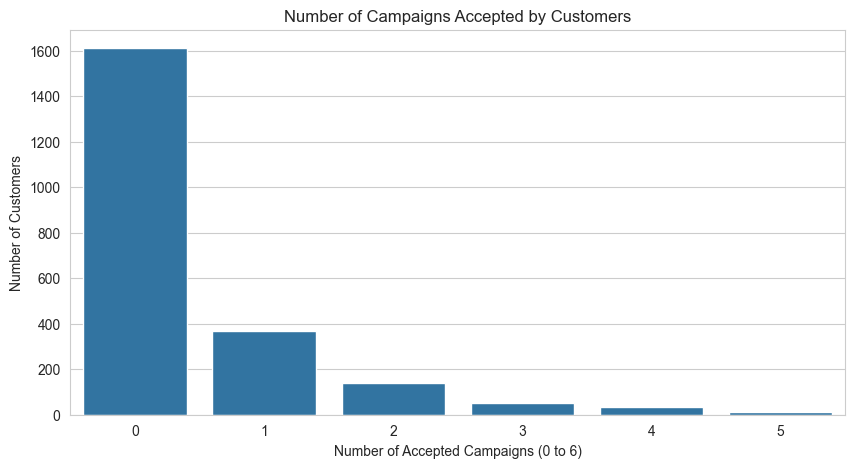

In [18]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Acceptany', data=df)
plt.title('Number of Campaigns Accepted by Customers')
plt.xlabel('Number of Accepted Campaigns (0 to 6)')
plt.ylabel('Number of Customers')
plt.show()


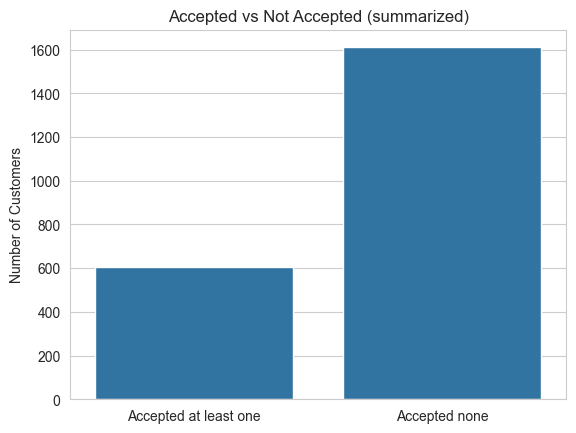

Percentage of customers who accepted at least one campaign: 27.30%


In [19]:
accepted = (df['Acceptany'] > 0).sum()
not_accepted = (df['Acceptany'] == 0).sum()

sns.barplot(x=['Accepted at least one', 'Accepted none'], y=[accepted, not_accepted])
plt.ylabel('Number of Customers')
plt.title('Accepted vs Not Accepted (summarized)')
plt.show()

percentage = (df['Acceptany'] > 0).mean() * 100
print(f"Percentage of customers who accepted at least one campaign: {percentage:.2f}%")


## now we have one columns has clear to response of customer 

### total_spending



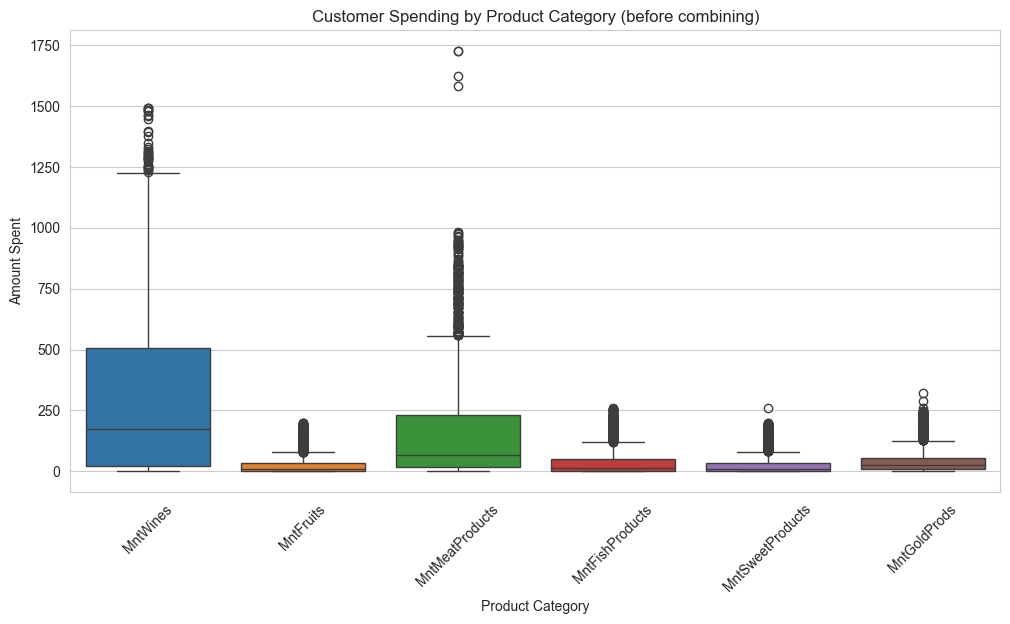

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['MntWines','MntFruits','MntMeatProducts',
                      'MntFishProducts','MntSweetProducts','MntGoldProds']])
plt.xticks(rotation=45)
plt.xlabel('Product Category')
plt.ylabel('Amount Spent')
plt.title('Customer Spending by Product Category (before combining)')
plt.show()


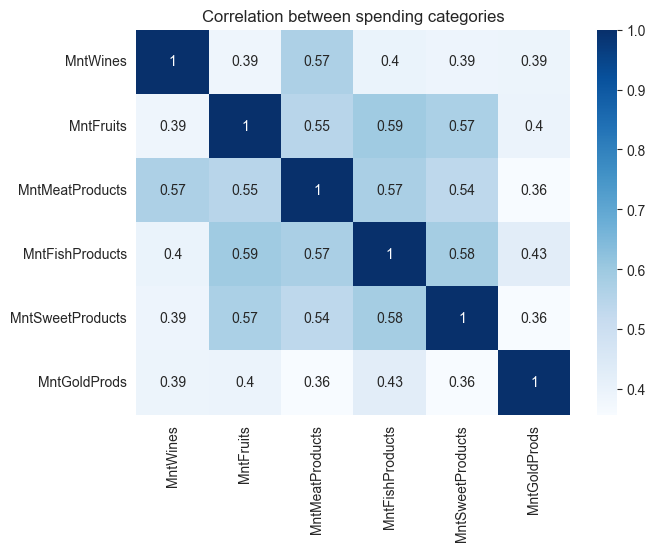

In [21]:
spend_cols = ['MntWines','MntFruits','MntMeatProducts',
              'MntFishProducts','MntSweetProducts','MntGoldProds']

corr_spend = df[spend_cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr_spend, annot=True, cmap='Blues')
plt.title('Correlation between spending categories')
plt.show()


**Observation from the two charts:** All the `Mnt*` columns move in the same direction (a customer who spends a lot on one thing generally spends a lot overall) and they have a clear positive correlation with each other, and they're all roughly Right-skewed in the same way. Using them separately would introduce redundancy in clustering distance and give more weight to the 'spending' behavior than other variables. Solution: combine them into a single column representing the total customer value.

In [22]:
df['total_spending'] = df[
    ['MntWines','MntFruits','MntMeatProducts',
     'MntFishProducts','MntSweetProducts','MntGoldProds']
].sum(axis=1)

df[spend_cols + ['total_spending']].head()


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,total_spending
0,635,88,546,172,88,88,1617
1,11,1,6,2,1,6,27
2,426,49,127,111,21,42,776
3,11,4,20,10,3,5,53
4,173,43,118,46,27,15,422


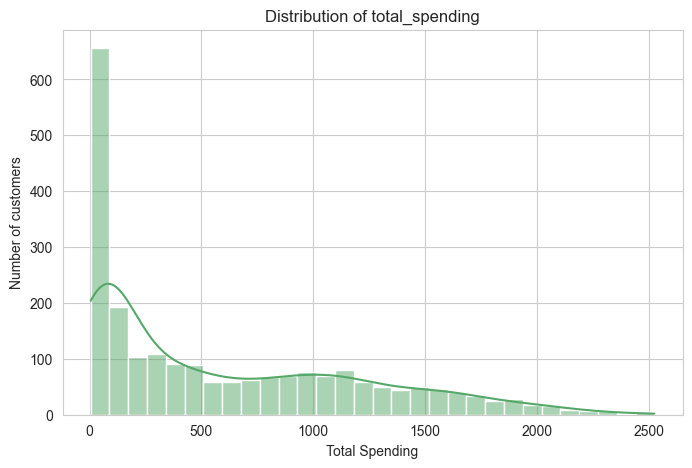

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(df['total_spending'], bins=30, kde=True, color='#55A868')
plt.title('Distribution of total_spending')
plt.xlabel('Total Spending')
plt.ylabel('Number of customers')
plt.show()


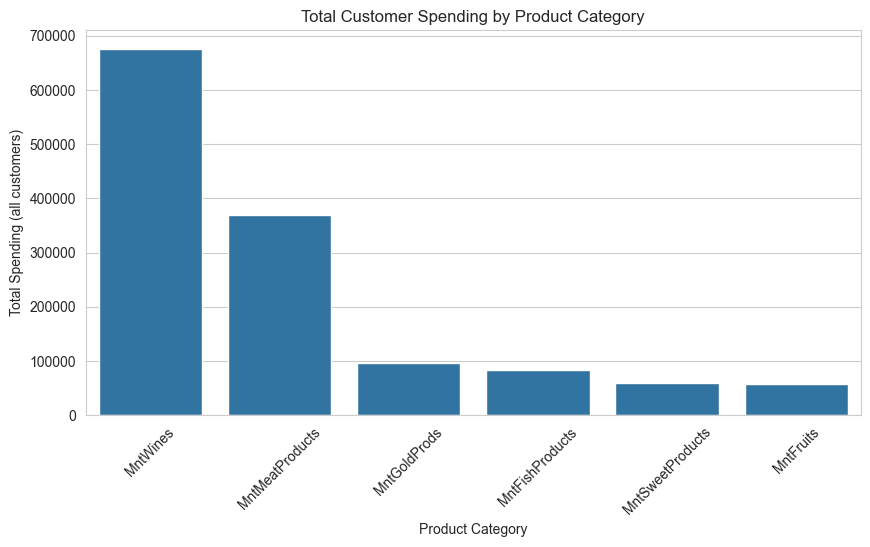

In [24]:
total_by_cat = df[spend_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=total_by_cat.index, y=total_by_cat.values)
plt.xticks(rotation=45)
plt.xlabel('Product Category')
plt.ylabel('Total Spending (all customers)')
plt.title('Total Customer Spending by Product Category')
plt.show()


## (High-value customers versus low-value ones),

### total_childern


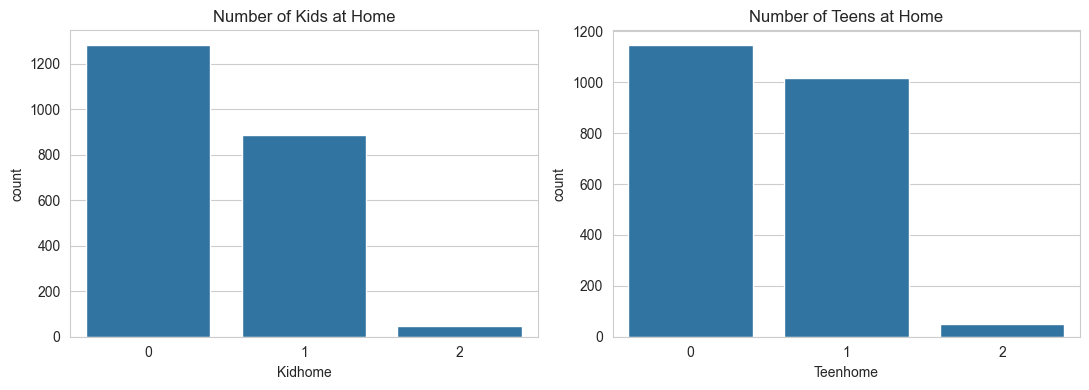

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='Kidhome', data=df, ax=axes[0])
axes[0].set_title('Number of Kids at Home')
axes[0].set_xlabel('Kidhome')

sns.countplot(x='Teenhome', data=df, ax=axes[1])
axes[1].set_title('Number of Teens at Home')
axes[1].set_xlabel('Teenhome')
plt.tight_layout()
plt.show()


## We combine them into one column instead of using them as two separate variables that repeat the same meaning.

In [26]:
df['total_childern'] = df['Teenhome'] + df['Kidhome']
df[['Kidhome','Teenhome','total_childern']].head()


,Kidhome,Teenhome,total_childern
0,0,0,0
1,1,1,2
2,0,0,0
3,1,0,1
4,1,0,1


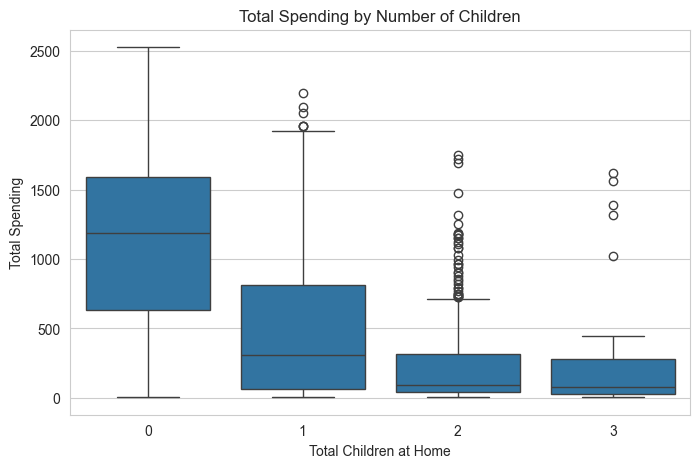

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='total_childern', y='total_spending', data=df)
plt.xlabel('Total Children at Home')
plt.ylabel('Total Spending')
plt.title('Total Spending by Number of Children')
plt.show()


The more kids there are, the more `total_children` really affects customer behavior, and putting it in a single column is cleaner and stronger than using `Kidhome` and `Teenhome` separately, plus it reduces the redundancy between them.

##  (Outliers)


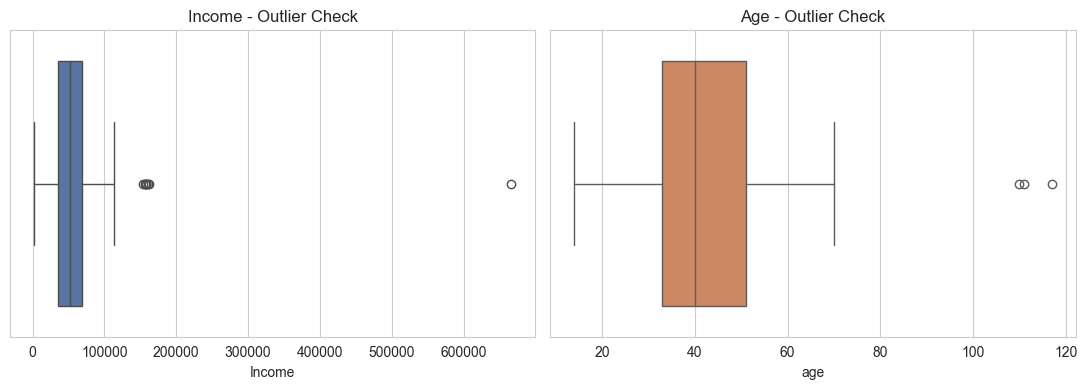

In [28]:
df['age'] = 2010 - df['Year_Birth']   

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df['Income'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Income - Outlier Check')

sns.boxplot(x=df['age'], ax=axes[1], color='#DD8452')
axes[1].set_title('Age - Outlier Check')
plt.tight_layout()
plt.show()


In [29]:
df.nlargest(3, 'age')[['Year_Birth', 'age']]

,Year_Birth,age
239,1893,117
339,1899,111
192,1900,110


In [30]:
df.nlargest(3, 'Income')[['Income']]

,Income
2233,666666.0
617,162397.0
687,160803.0


## Distribution of numerical columns

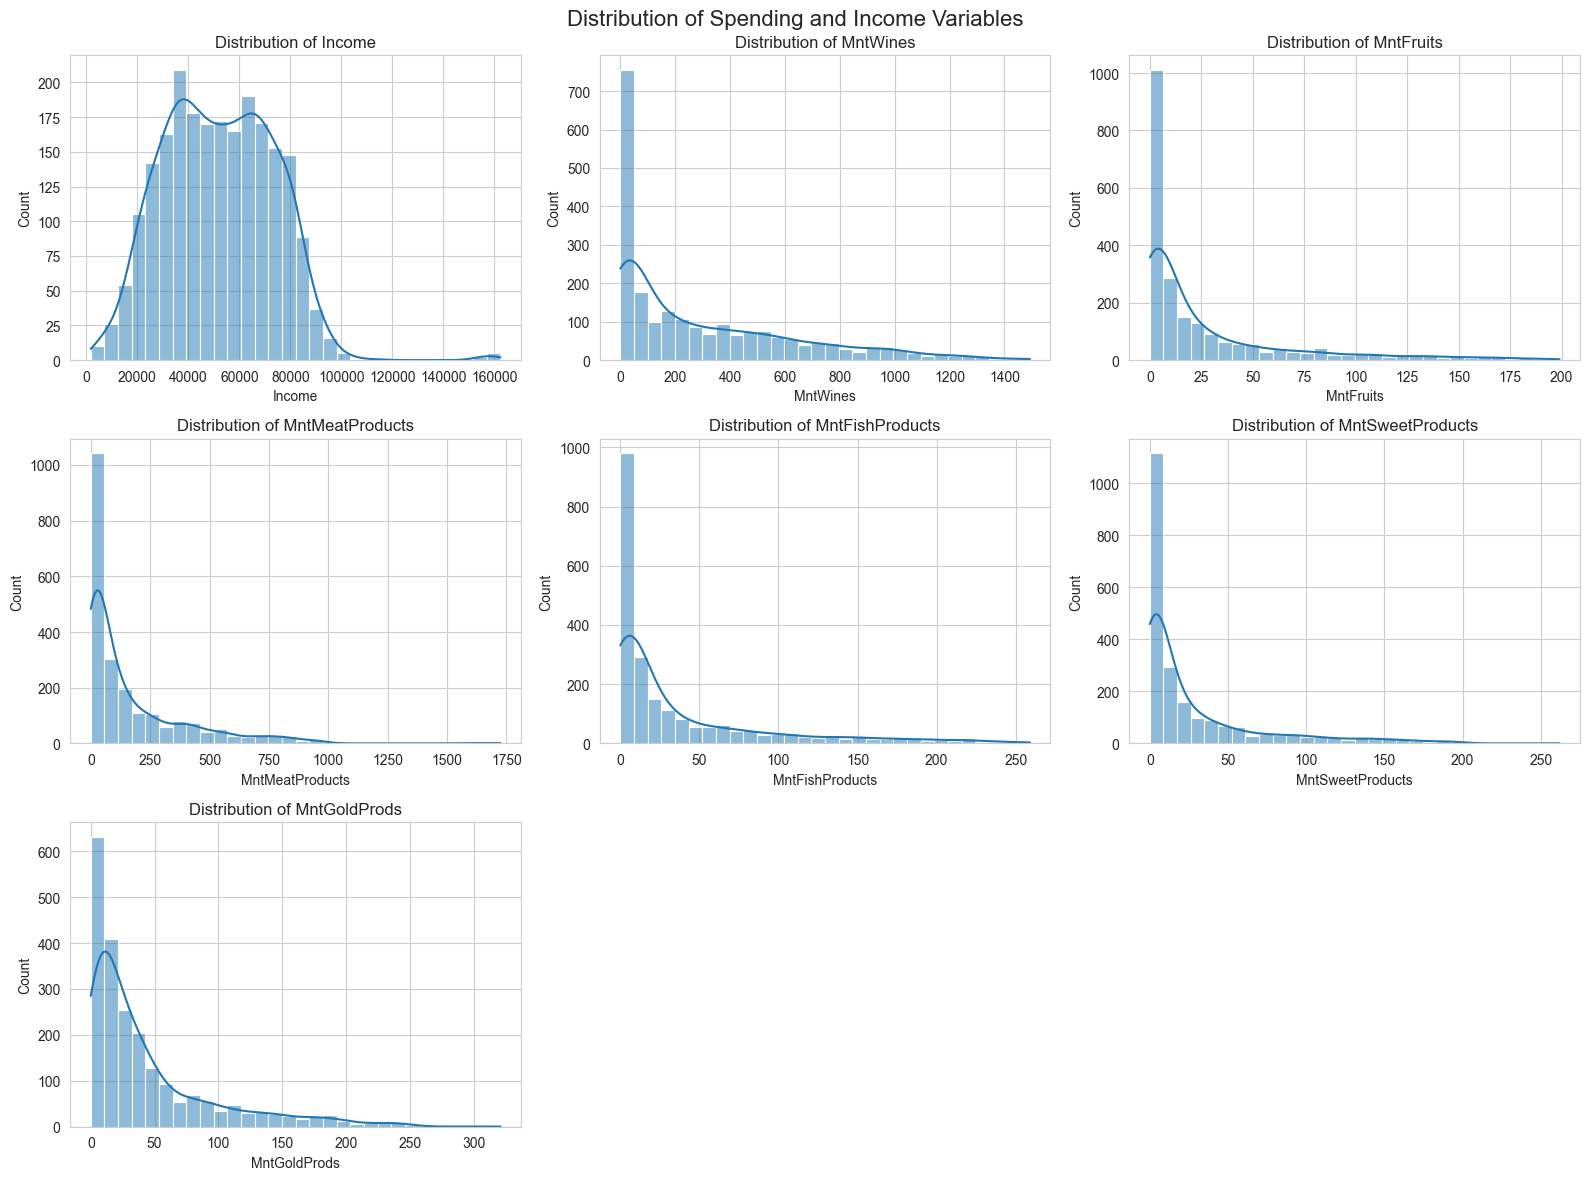

In [32]:
spend_list = ['Income','MntWines','MntFruits','MntMeatProducts',
              'MntFishProducts','MntSweetProducts','MntGoldProds']

n_cols = 3
n_rows = int(np.ceil(len(spend_list) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(spend_list):
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(len(spend_list), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Spending and Income Variables', fontsize=16)
plt.tight_layout()
plt.show()


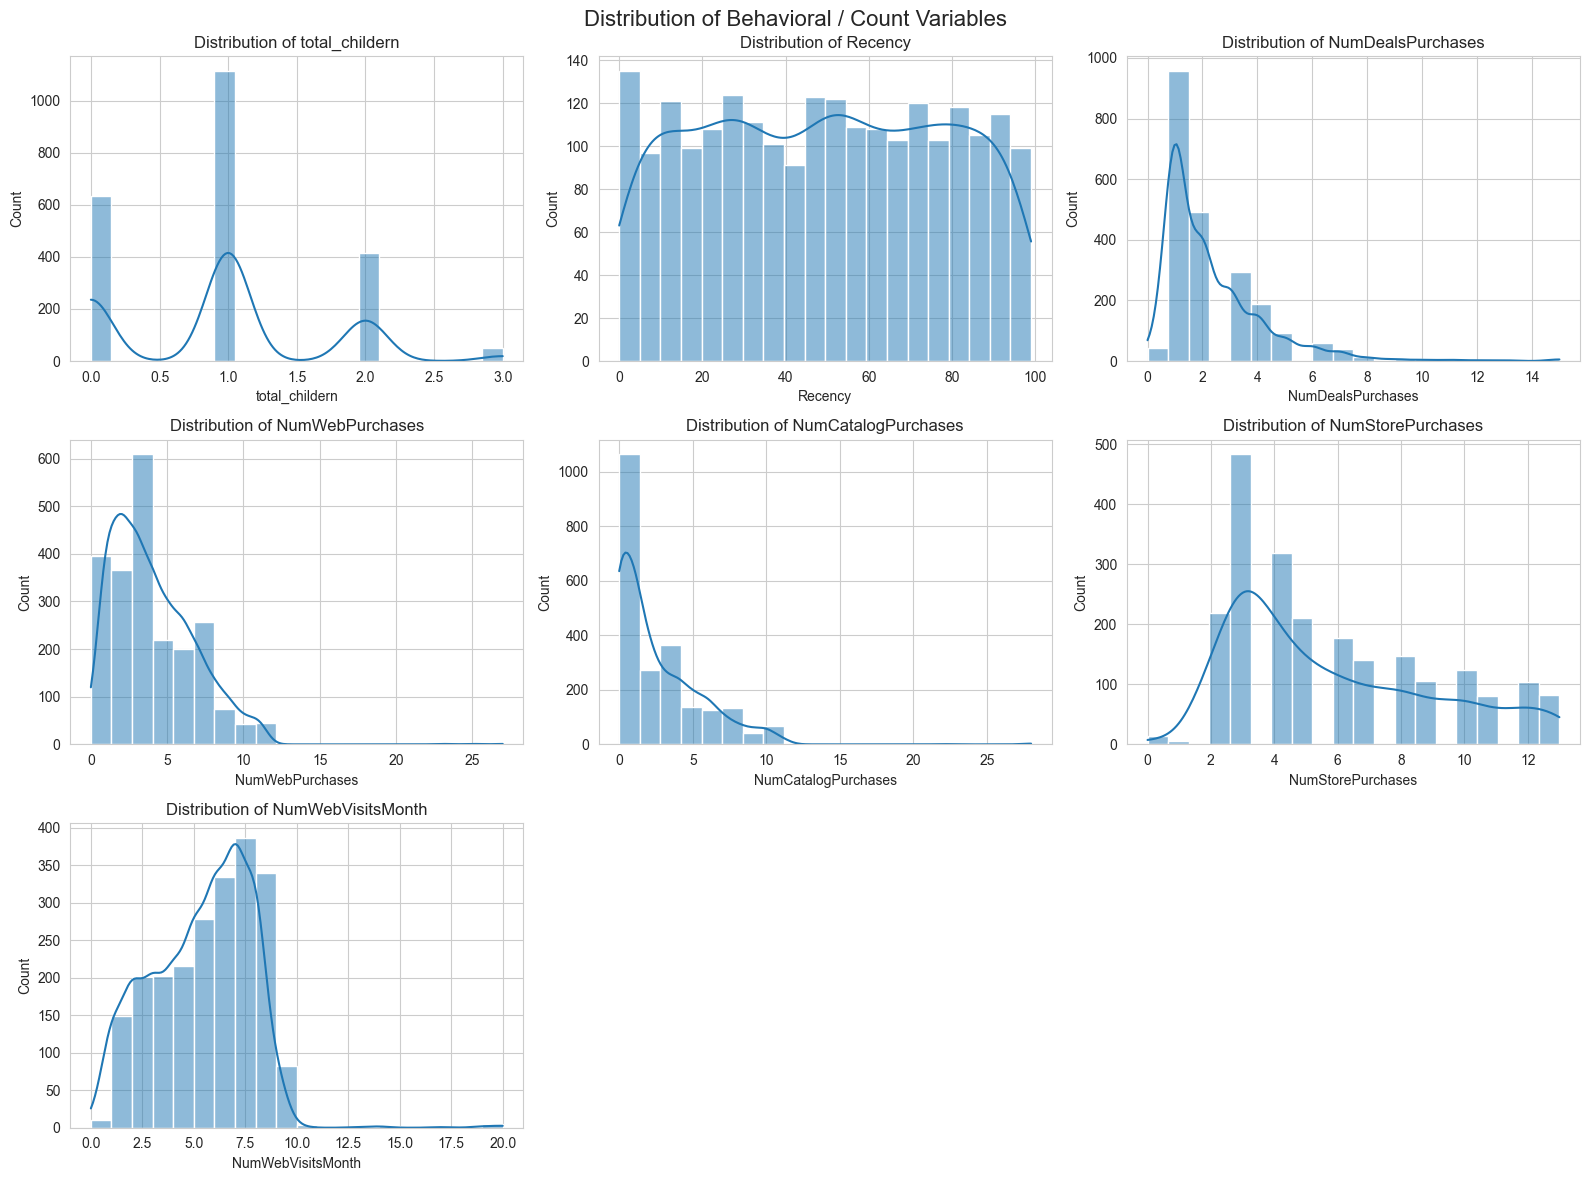

In [33]:
count_list = ['total_childern','Recency','NumDealsPurchases','NumWebPurchases',
              'NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth']

n_cols = 3
n_rows = int(np.ceil(len(count_list) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(count_list):
    sns.histplot(data=df, x=col, bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(len(count_list), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Behavioral / Count Variables', fontsize=16)
plt.tight_layout()
plt.show()


In [34]:
skew_cols = spend_list + ['total_spending']
df[skew_cols].skew().sort_values(ascending=False)


MntFruits           2.103864
MntSweetProducts    2.102925
MntMeatProducts     2.027563
MntFishProducts     1.916558
MntGoldProds        1.837728
MntWines            1.170977
total_spending      0.857382
Income              0.348028
dtype: float64

The spending columns (`Mnt*` and `total_spending`) have high skewness (right-skewed) — it's important to keep this in mind during clustering. We'll need to apply a `log1p` transform to them before using StandardScaler so that outliers don't dominate the distance.

## (Correlation)

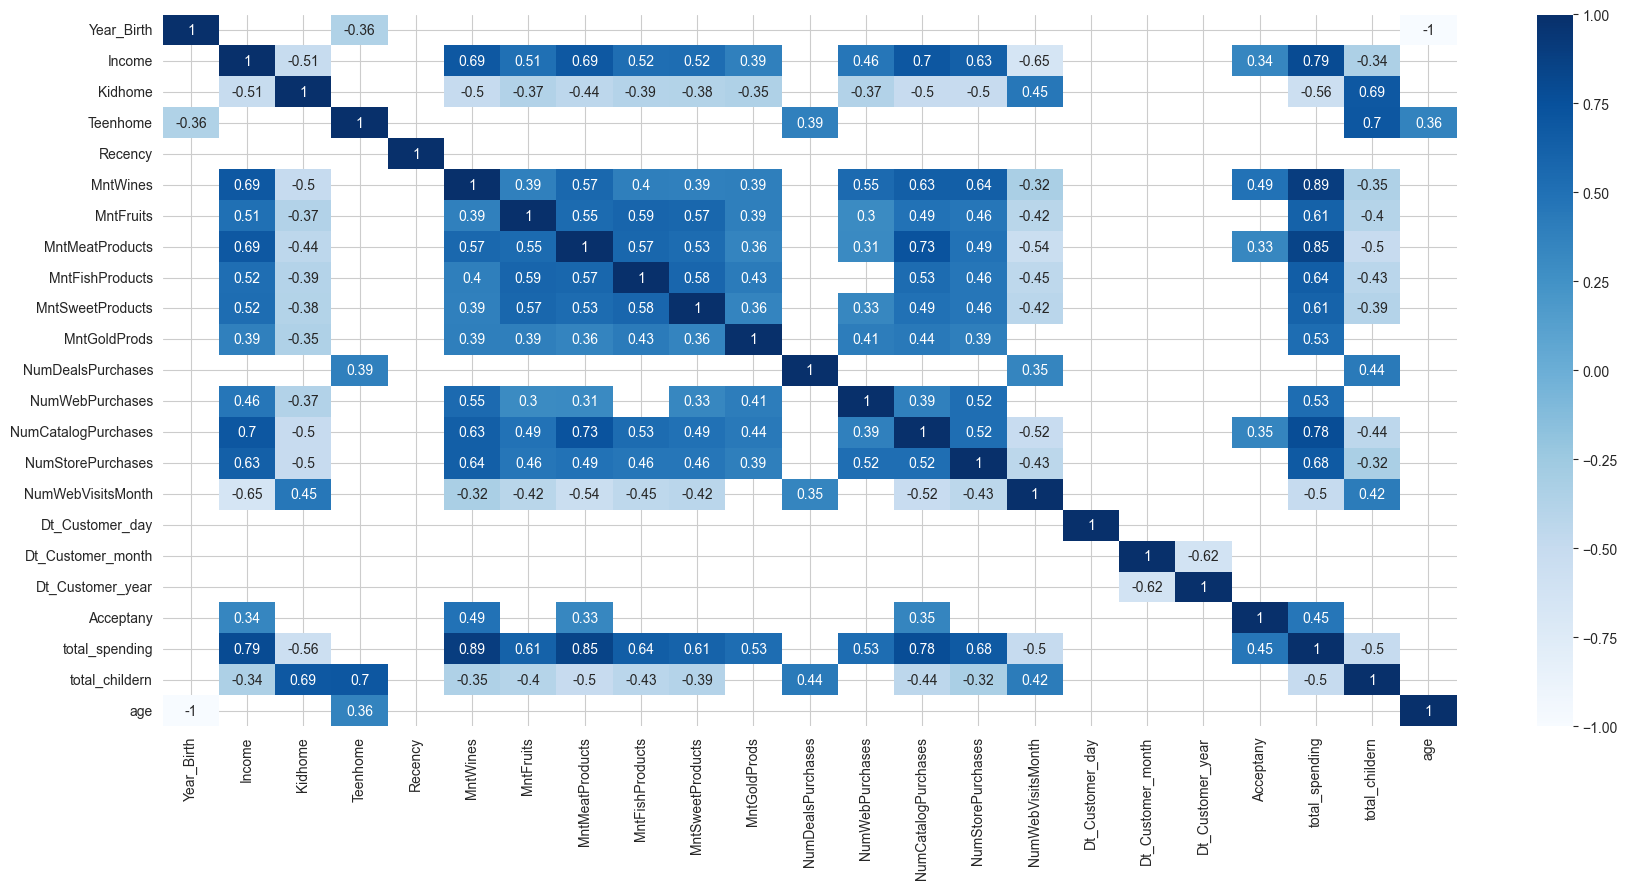

In [35]:
binary_cols_final = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
                     'AcceptedCmp4','AcceptedCmp5','Response','Complain']

corr_columns = [c for c in df.select_dtypes(include=np.number).columns if c not in binary_cols_final]

plt.figure(figsize=(18, 9))
corr = df[corr_columns].corr()
sns.heatmap(corr[(corr > 0.30) | (corr < -0.30)], annot=True, cmap='Blues')
plt.tight_layout()
plt.show()


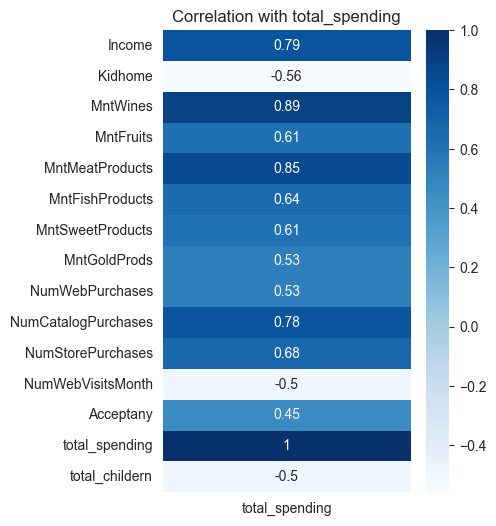

In [36]:
corr_total_spending = df[corr_columns].corr()['total_spending']
filtered = corr_total_spending[(corr_total_spending > 0.30) | (corr_total_spending < -0.30)]

plt.figure(figsize=(4, 6))
sns.heatmap(filtered.to_frame(), annot=True, cmap='Blues')
plt.title('Correlation with total_spending')
plt.show()


## 8. تحليل حسب الفئة العمرية

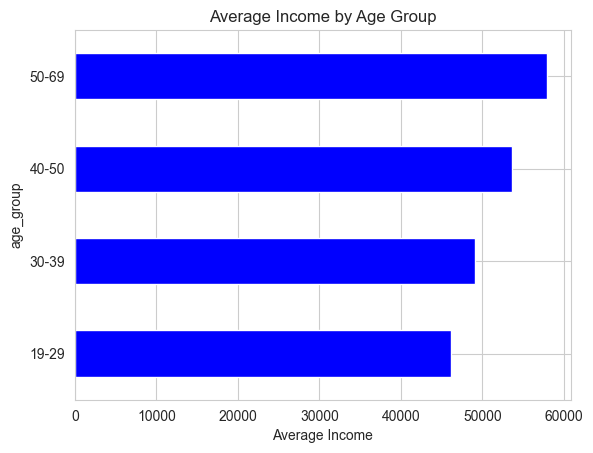

In [39]:
labels = ['19-29','30-39','40-50','50-69','70+']
df['age_group'] = pd.cut(df['age'], bins=[18,30,40,50,70,90], labels=labels)

group_income = df.groupby('age_group', observed=True)['Income'].mean()
group_income.plot(kind='barh', color='blue')
plt.xlabel('Average Income')
plt.title('Average Income by Age Group')
plt.show()


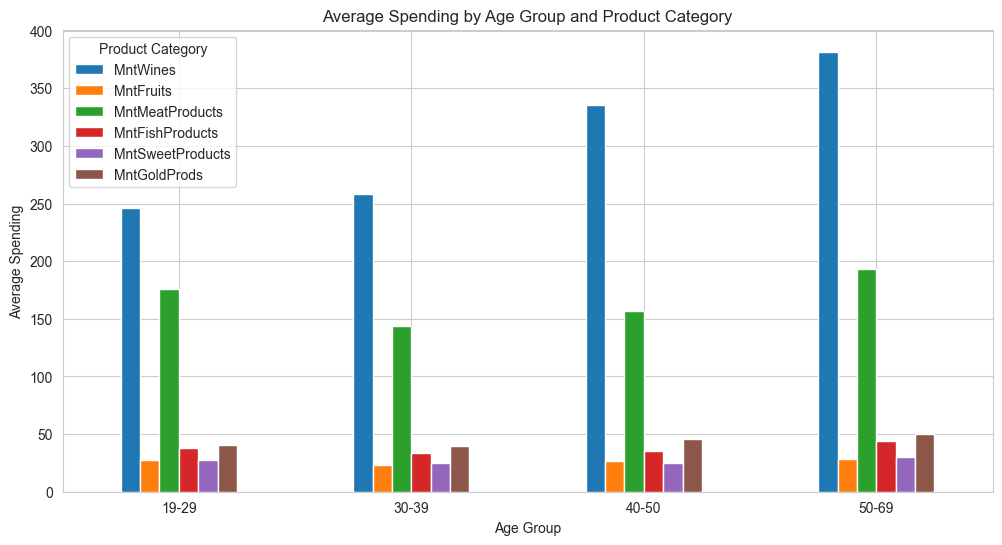

In [40]:
group_spending = df.groupby('age_group', observed=True)[spend_cols].mean()

group_spending.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Age Group')
plt.ylabel('Average Spending')
plt.title('Average Spending by Age Group and Product Category')
plt.xticks(rotation=0)
plt.legend(title='Product Category')
plt.show()


## 9. Summary — What's Ready for Clustering

**The new columns we created and what they mean:**
- `Acceptany` (0-6): Overall marketing responsiveness of the customer, instead of 6 weak binary columns.
- `total_spending`: The total value of the customer, instead of 6 strongly correlated spending columns.
- `total_childern`: Presence/number of children at home, instead of two columns (`Kidhome`, `Teenhome`) that measure the same idea.

 we should remmeber 
1. Apply `log1p` on the skewed spending columns (`Mnt*`, `total_spending`).
2. Encode `Education` and `Marital_Status` if we plan to use them.
3. Choose the final columns (we can drop the original `Mnt*` and `Kidhome`/`Teenhome` and `AcceptedCmp*` columns after making their summaries, to avoid duplicating the same signal twice).
4. Apply `StandardScaler` on all the final numeric columns.
5. Optionally use `PCA` to reduce dimensions before `KMeans`.

## Preprocessing

In [41]:
skew_cols = ['MntWines','MntFruits','MntMeatProducts',
             'MntFishProducts','MntSweetProducts','MntGoldProds','total_spending']

for col in skew_cols:
    df[col + '_log'] = np.log1p(df[col])

In [42]:
from sklearn.preprocessing import OrdinalEncoder

education_order = [['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']]
ordinal_enc = OrdinalEncoder(categories=education_order, handle_unknown='use_encoded_value', unknown_value=-1)
df['Education_encoded'] = ordinal_enc.fit_transform(df[['Education']])

df = pd.get_dummies(df, columns=['Marital_Status'], prefix='Marital', drop_first=True)

In [43]:
drop_cols = [
    'MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds',
    'total_spending',
    'Kidhome','Teenhome',
    'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response',
    'Education',
    'Dt_Customer','Dt_Customer_day','Dt_Customer_month','Dt_Customer_year',
    'Year_Birth','age_group'
]

cluster_df = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [87]:
cluster_df.columns

Index(['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Acceptany', 'total_childern', 'age', 'MntWines_log',
       'MntFruits_log', 'MntMeatProducts_log', 'MntFishProducts_log',
       'MntSweetProducts_log', 'MntGoldProds_log', 'total_spending_log',
       'Education_encoded', 'Marital_Alone', 'Marital_Divorced',
       'Marital_Married', 'Marital_Single', 'Marital_Together',
       'Marital_Widow', 'Marital_YOLO'],
      dtype='object')

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_array = scaler.fit_transform(cluster_df)
scaled_df = pd.DataFrame(scaled_array, columns=cluster_df.columns, index=cluster_df.index)

In [89]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90, random_state=42)
pca_array = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(pca_array, columns=[f'PC{i+1}' for i in range(pca.n_components_)])
print('Number of components kept:', pca.n_components_)

Number of components kept: 16


In [90]:
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,3.819029,-0.359801,0.470998,-1.499014,1.618851,-0.025593,0.650945,0.253838,0.028164,-0.136913,-0.312749,0.288682,1.341719,0.704143,1.991620,0.057803
1,-3.421139,-0.361805,-1.030751,-0.260230,1.354314,0.126361,1.111842,0.130458,-0.023050,0.064717,0.272928,-1.290052,1.675421,-0.690318,-0.177465,-0.022151
2,2.727013,-0.485467,-0.683233,-1.099730,-1.489494,-0.554985,-0.518220,0.364494,-0.172233,0.079908,0.104447,-0.961299,-0.263685,1.394318,-0.758362,-0.256629
3,-2.667932,-1.116547,-0.447919,-1.181863,-1.225119,-0.878021,-0.884091,0.273610,-0.057209,-0.071840,-0.198230,-0.426036,-0.959355,-0.161762,0.020806,-0.284171
4,1.034995,0.726174,1.372838,0.794004,-0.321352,-0.227739,0.986568,-1.081329,0.204282,-0.723976,0.629849,0.761852,-1.459440,-0.397425,1.160761,-0.706605


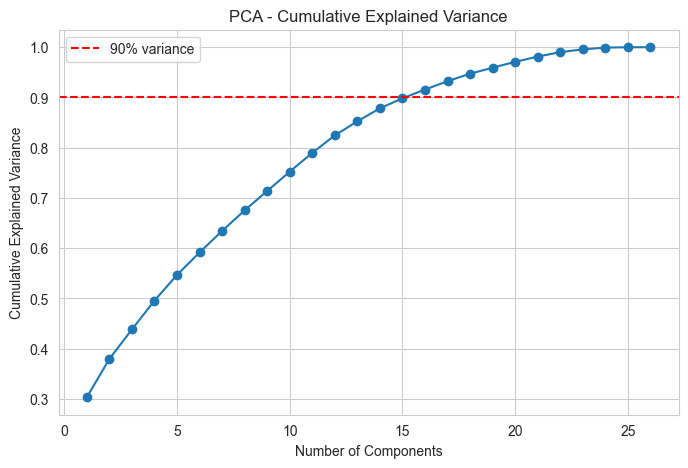

In [91]:
pca_full = PCA(random_state=42).fit(scaled_df)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.show()

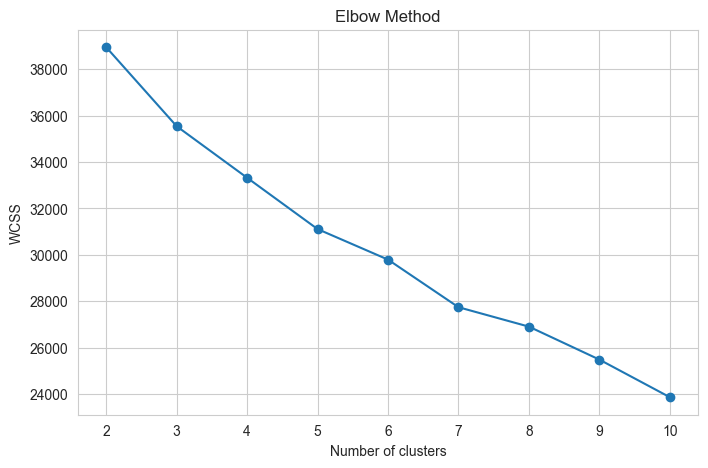

In [92]:
from sklearn.cluster import KMeans

wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(pca_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


In [93]:
# 7 

In [94]:
n_clusters =7  

kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(pca_df)

df['cluster'].value_counts().sort_index()


cluster
0    690
1    441
2      3
3    612
4      2
5    444
6     20
Name: count, dtype: int64

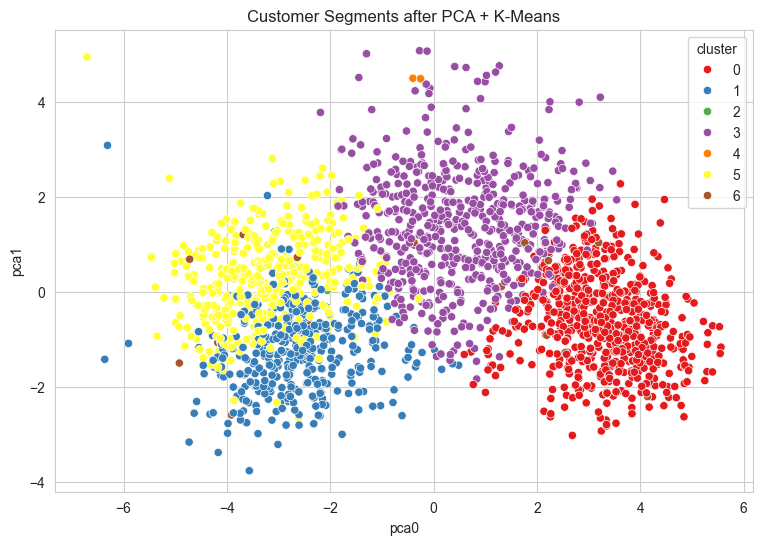

In [95]:
# تصغير الأبعاد لـ 2D بس عشان الرسم (مش للتدريب)
pca_2d = PCA(n_components=2, random_state=42)
pca_data = pca_2d.fit_transform(pca_df)
df['pca0'], df['pca1'] = pca_data[:, 0], pca_data[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='pca0', y='pca1', hue='cluster', palette='Set1')
plt.title("Customer Segments after PCA + K-Means")
plt.show()


1️⃣ PCA (first image) — weak compression

To reach 90% of the variance, you need about 15 components out of 26 — meaning PCA didn't reduce the dimensions much. This is normal and happens when you have:

- A lot of dummy variable columns from Marital_Status's get_dummies (each column is almost independent from the others, so there's no shared variance to summarize).
- Columns that aren't related at all (like Complain, NumWebVisitsMonth).

It's not wrong, but it means that PCA in this case won't make much difference compared to just using the original (scaled) columns directly for clustering.

In [99]:
cluster_df.columns.tolist()

['Income',
 'Recency',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'Complain',
 'Acceptany',
 'total_childern',
 'age',
 'MntWines_log',
 'MntFruits_log',
 'MntMeatProducts_log',
 'MntFishProducts_log',
 'MntSweetProducts_log',
 'MntGoldProds_log',
 'total_spending_log',
 'Education_encoded',
 'Marital_Alone',
 'Marital_Divorced',
 'Marital_Married',
 'Marital_Single',
 'Marital_Together',
 'Marital_Widow',
 'Marital_YOLO']

In [100]:
cluster_df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Acceptany,total_childern,...,MntGoldProds_log,total_spending_log,Education_encoded,Marital_Alone,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Marital_YOLO
0,58138.0,58,3,8,10,4,7,0,1,0,...,4.488636,7.388946,2.0,False,False,False,True,False,False,False
1,46344.0,38,2,1,1,2,5,0,0,2,...,1.945910,3.332205,2.0,False,False,False,True,False,False,False
2,71613.0,26,1,8,2,10,4,0,0,0,...,3.761200,6.655440,2.0,False,False,False,False,True,False,False
3,26646.0,26,2,2,0,4,6,0,0,1,...,1.791759,3.988984,2.0,False,False,False,False,True,False,False
4,58293.0,94,5,5,3,6,5,0,0,1,...,2.772589,6.047372,4.0,False,False,True,False,False,False,False


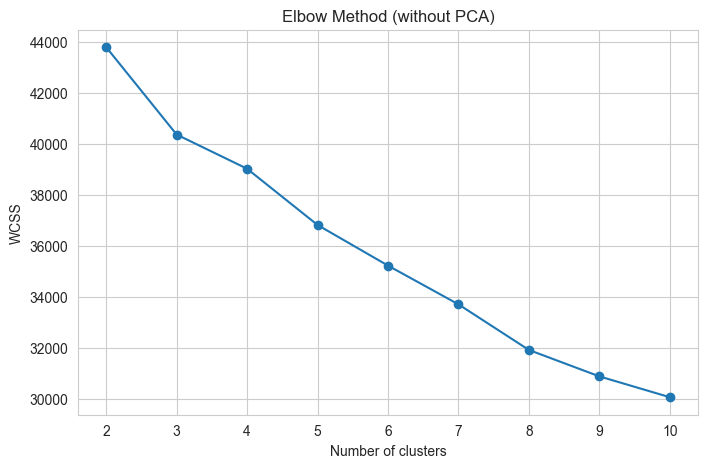

In [101]:
wcss_no_pca = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss_no_pca.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss_no_pca, marker='o')
plt.title('Elbow Method (without PCA)')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


k=2 -> silhouette=0.2356
k=3 -> silhouette=0.1659
k=4 -> silhouette=0.1086
k=5 -> silhouette=0.1098
k=6 -> silhouette=0.1510
k=7 -> silhouette=0.1199
k=8 -> silhouette=0.1337
k=9 -> silhouette=0.1269
k=10 -> silhouette=0.1271


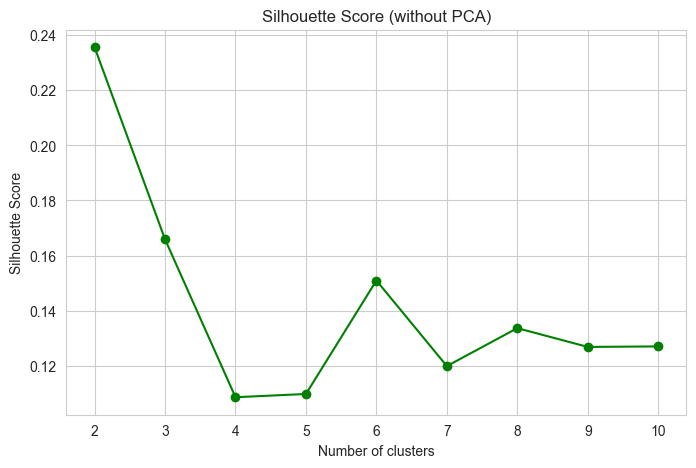

In [102]:
from sklearn.metrics import silhouette_score

sil_scores_no_pca = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    sil_scores_no_pca.append(score)
    print(f'k={i} -> silhouette={score:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores_no_pca, marker='o', color='green')
plt.title('Silhouette Score (without PCA)')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()


In [103]:
n_clusters =3 

kmeans_no_pca = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
df['cluster_no_pca'] = kmeans_no_pca.fit_predict(scaled_df)

df['cluster_no_pca'].value_counts().sort_index()


cluster_no_pca
0    630
1    714
2    868
Name: count, dtype: int64

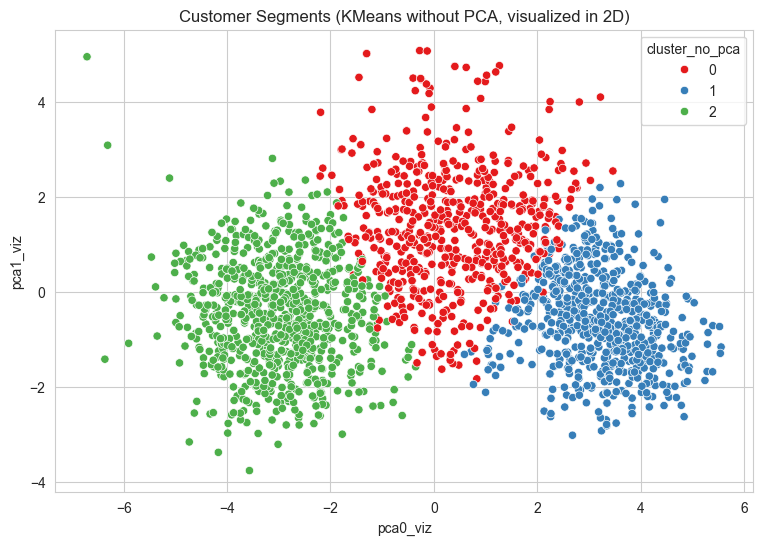

In [104]:
pca_viz = PCA(n_components=2, random_state=42)
viz_coords = pca_viz.fit_transform(scaled_df)
df['pca0_viz'], df['pca1_viz'] = viz_coords[:, 0], viz_coords[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='pca0_viz', y='pca1_viz', hue='cluster_no_pca', palette='Set1')
plt.title("Customer Segments (KMeans without PCA, visualized in 2D)")
plt.show()


In [105]:
profile_cols = ['Income', 'age', 'total_spending_log', 'total_childern', 'Acceptany', 'NumWebVisitsMonth']

df.groupby('cluster_no_pca')[profile_cols].mean().round(2)


,Income,age,total_spending_log,total_childern,Acceptany,NumWebVisitsMonth
cluster_no_pca,,,,,,
0,53687.38,44.63,6.21,1.24,0.40,6.20
1,73583.85,41.95,7.09,0.33,0.84,3.10
2,32915.87,37.80,4.00,1.24,0.16,6.51


In [106]:
cluster_stats = df.groupby('cluster')[cluster_df.columns].mean()
cluster_stats

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Acceptany,total_childern,...,MntGoldProds_log,total_spending_log,Education_encoded,Marital_Alone,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Marital_YOLO
cluster,,,,,,,,,,,,,,,,,,,,,
0,73893.402899,49.159420,1.415942,5.260870,5.663768,8.485507,3.030435,0.0,0.844928,0.304348,...,3.950286,7.096577,2.473913,0.0,0.097101,0.375362,0.224638,0.259420,0.040580,0.0
1,27430.646259,48.471655,1.861678,1.943311,0.462585,2.970522,6.848073,0.0,0.206349,0.884354,...,2.633934,4.159665,1.700680,0.0,0.049887,0.476190,0.290249,0.176871,0.006803,0.0
2,43789.000000,30.333333,3.666667,5.000000,0.666667,4.000000,6.333333,0.0,0.666667,1.666667,...,3.275571,4.954101,3.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,54468.681373,49.482026,3.973856,6.042484,2.594771,6.861111,6.160131,0.0,0.415033,1.248366,...,3.585531,6.266538,2.656863,0.0,0.129085,0.388889,0.178105,0.259804,0.044118,0.0
4,48432.000000,3.000000,5.000000,7.000000,1.000000,6.000000,8.000000,0.0,0.500000,1.000000,...,3.761200,6.052089,4.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
5,39128.409910,48.963964,1.898649,1.700450,0.371622,3.036036,6.166667,0.0,0.126126,1.578829,...,1.695998,3.936450,2.932432,0.0,0.139640,0.319820,0.162162,0.337838,0.040541,0.0
6,45672.400000,50.750000,2.400000,3.700000,2.100000,5.400000,5.850000,1.0,0.300000,1.200000,...,2.731718,5.046667,2.050000,0.0,0.050000,0.400000,0.300000,0.250000,0.000000,0.0


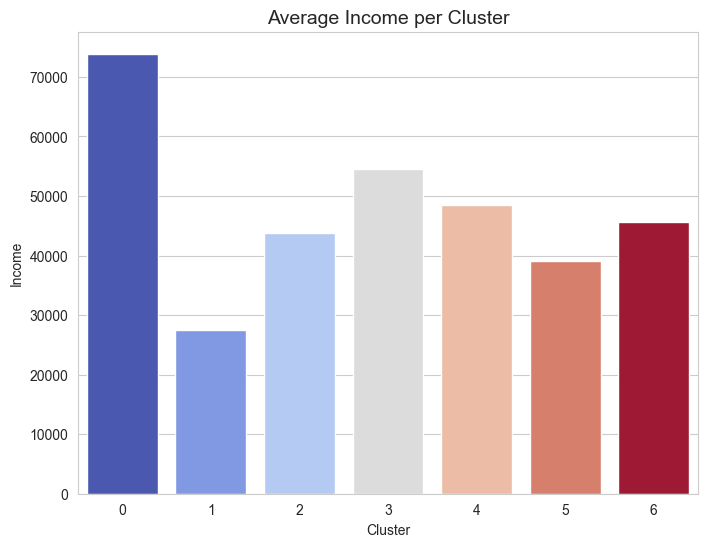

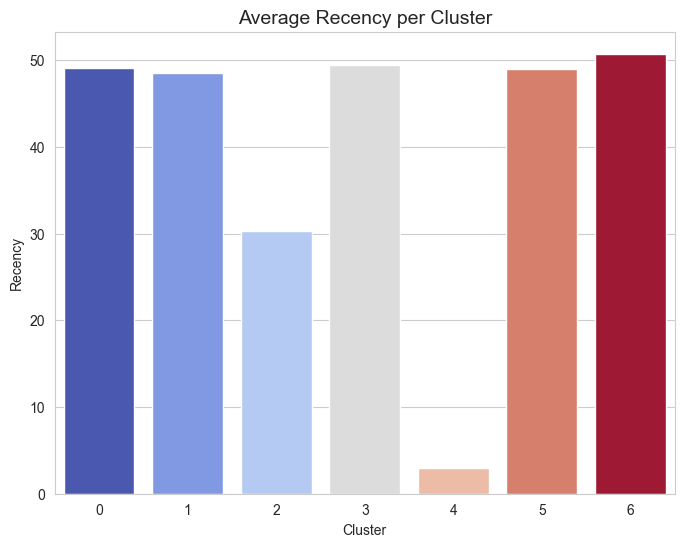

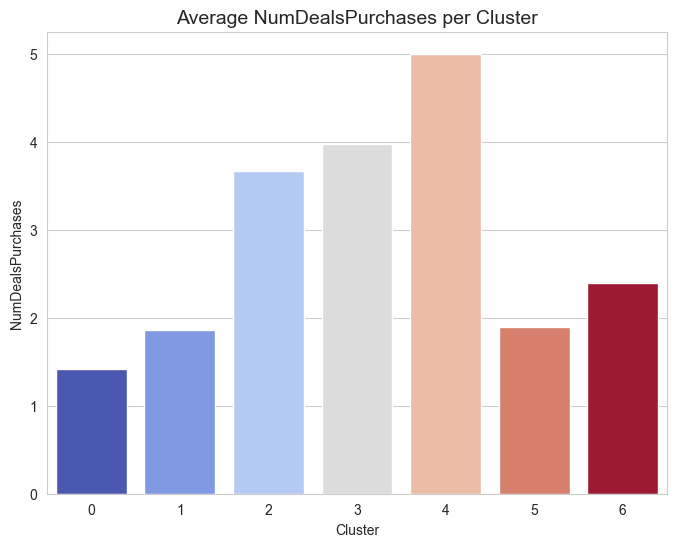

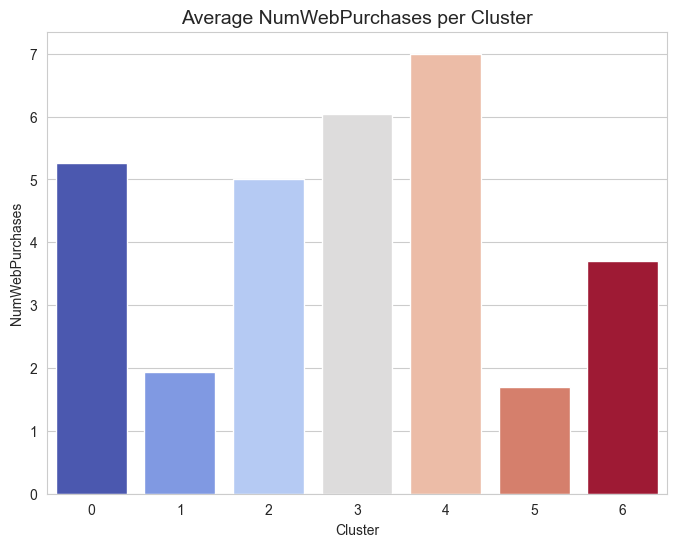

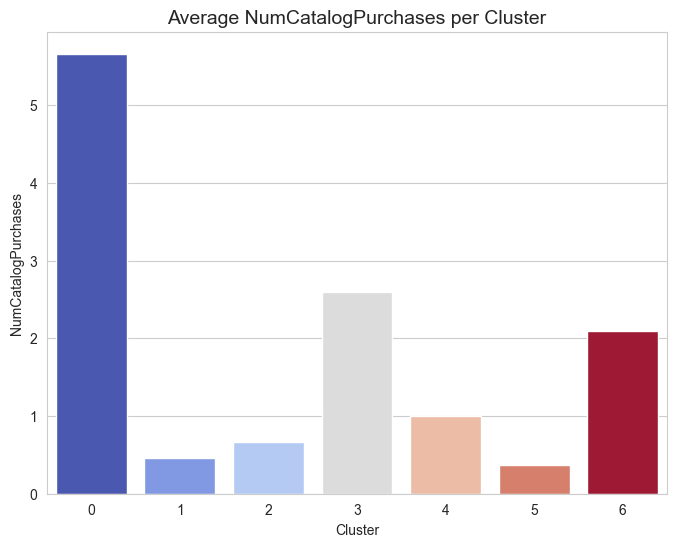

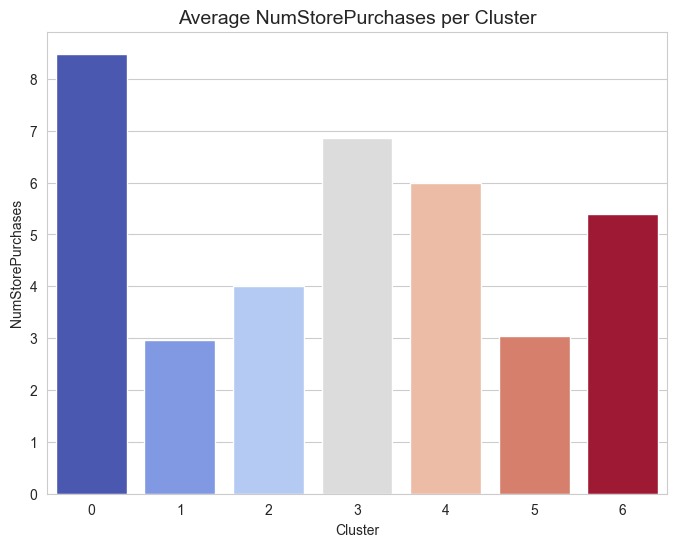

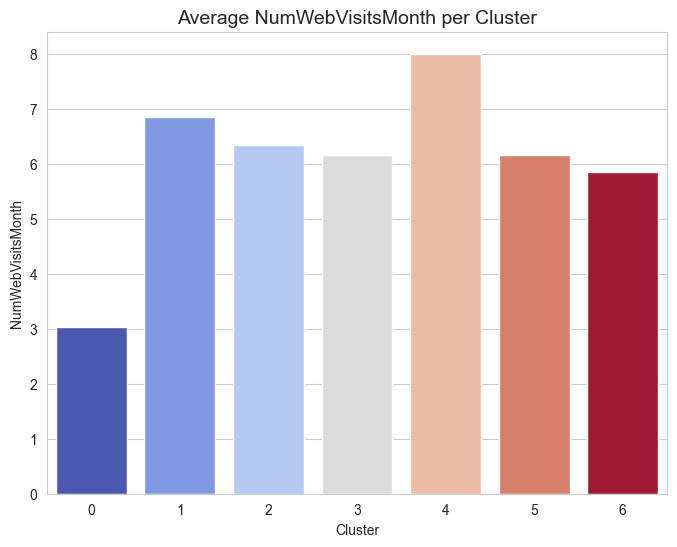

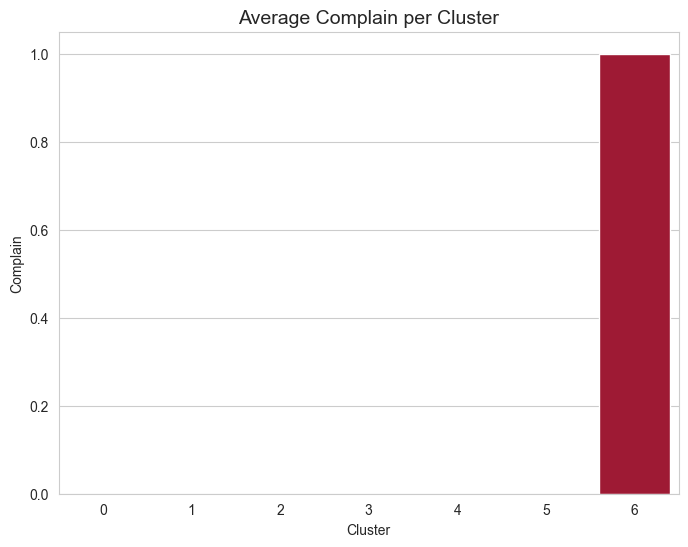

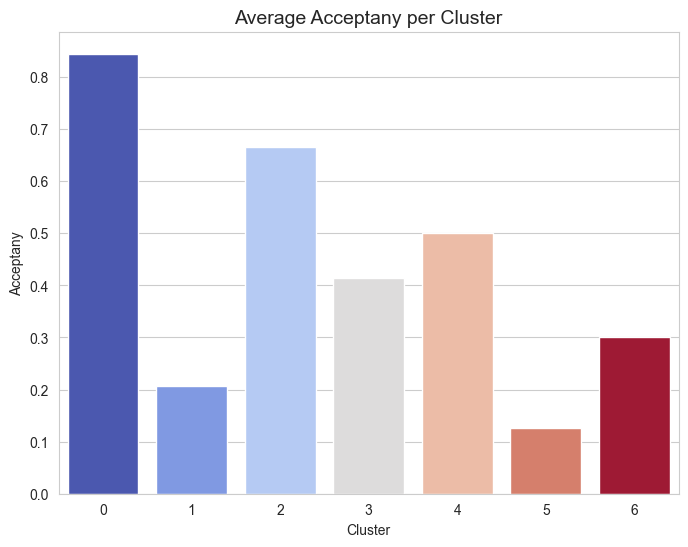

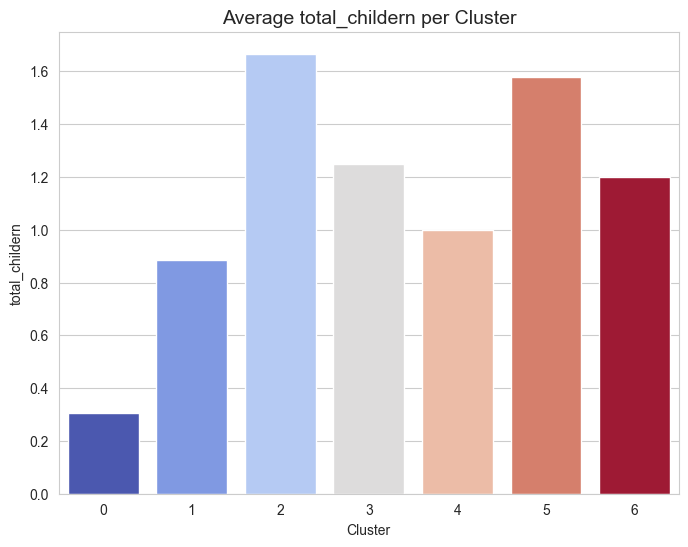

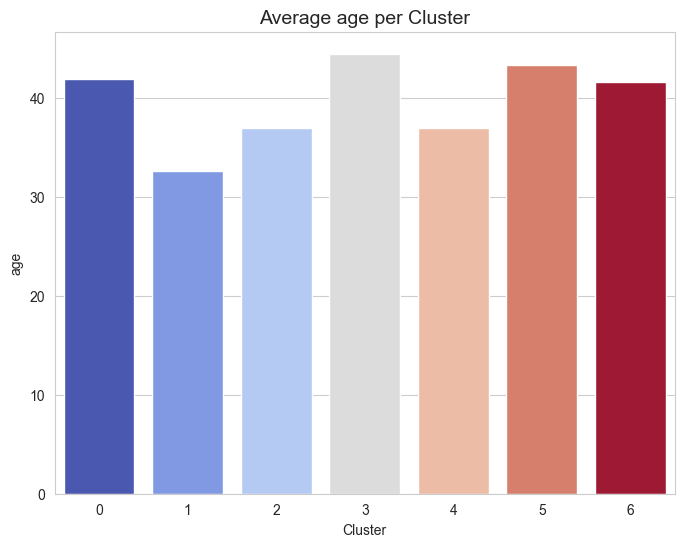

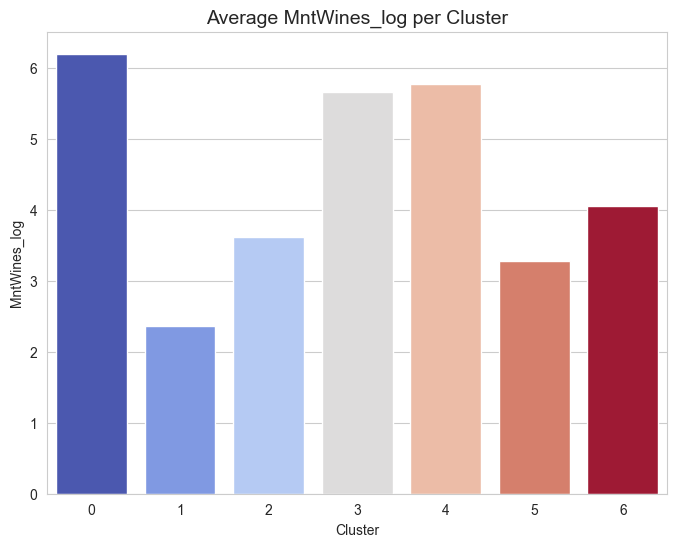

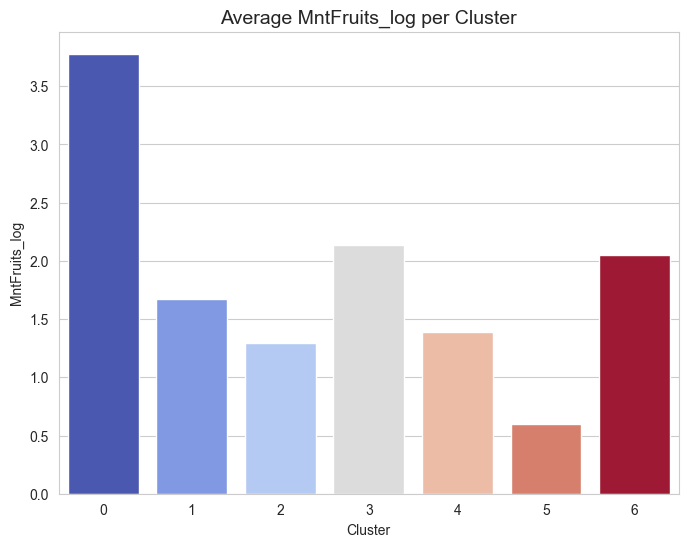

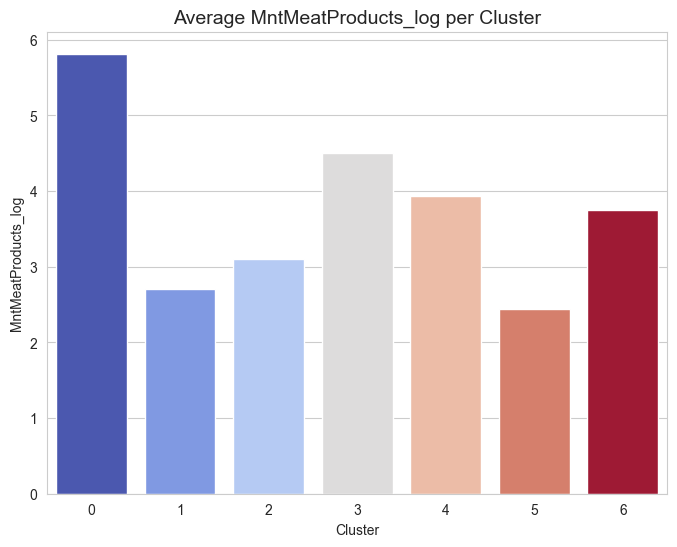

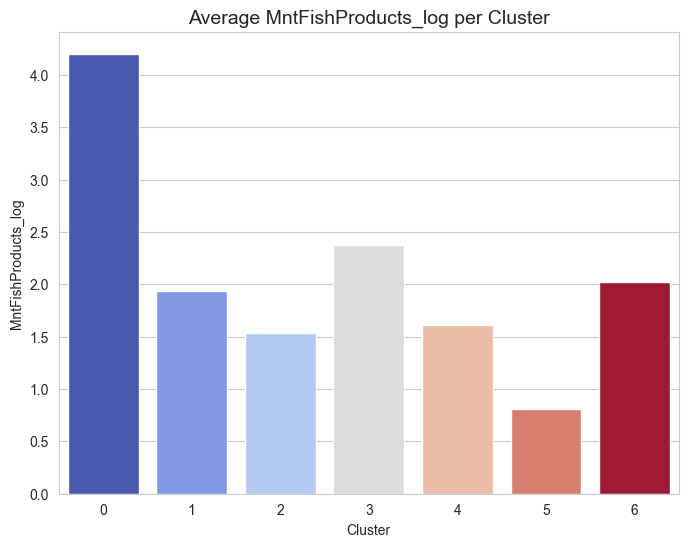

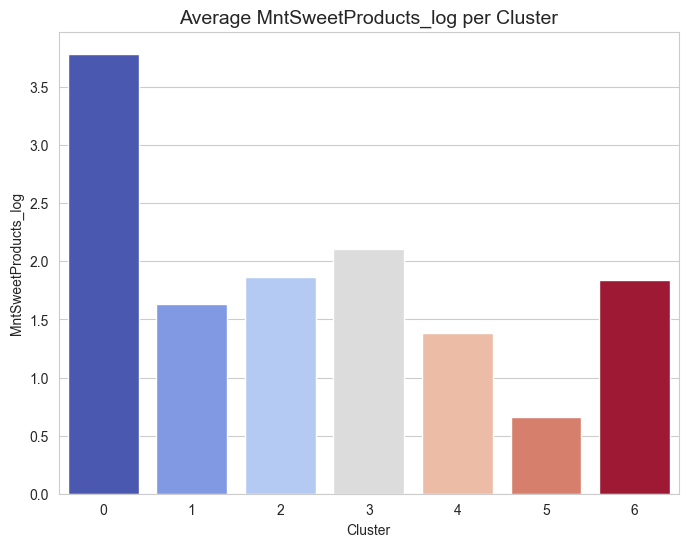

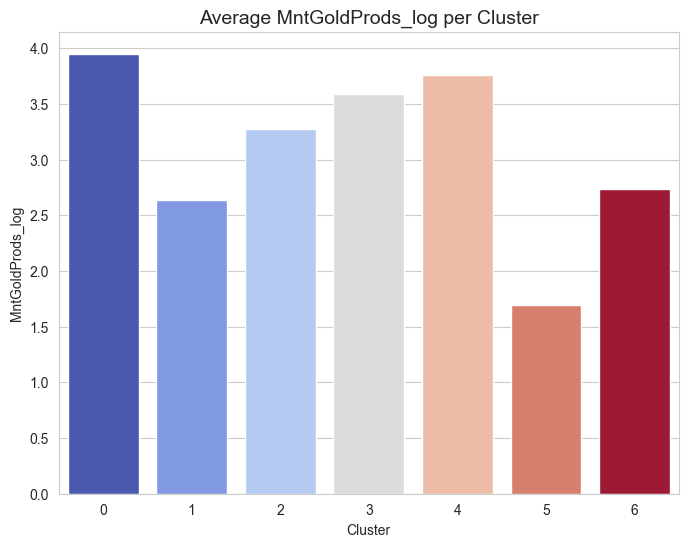

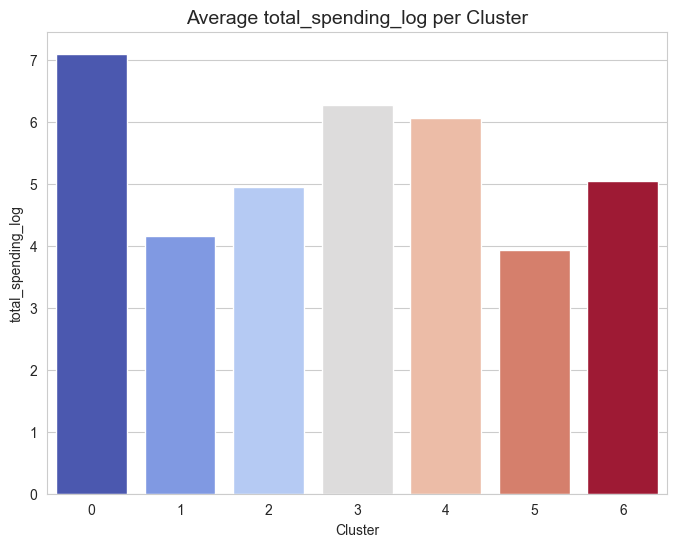

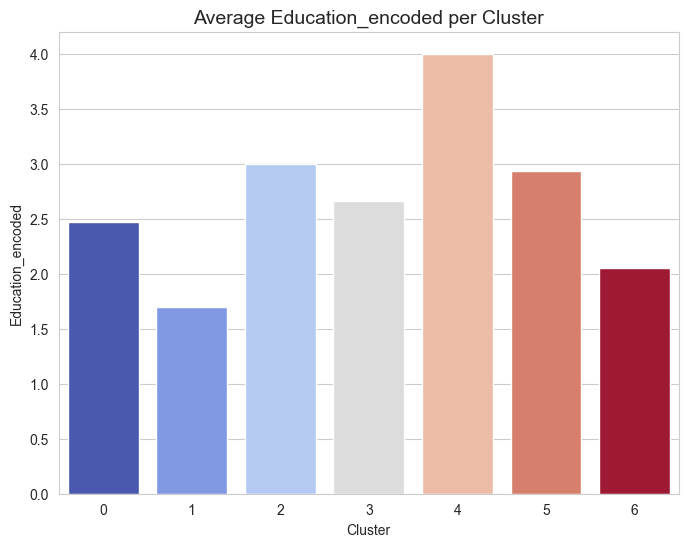

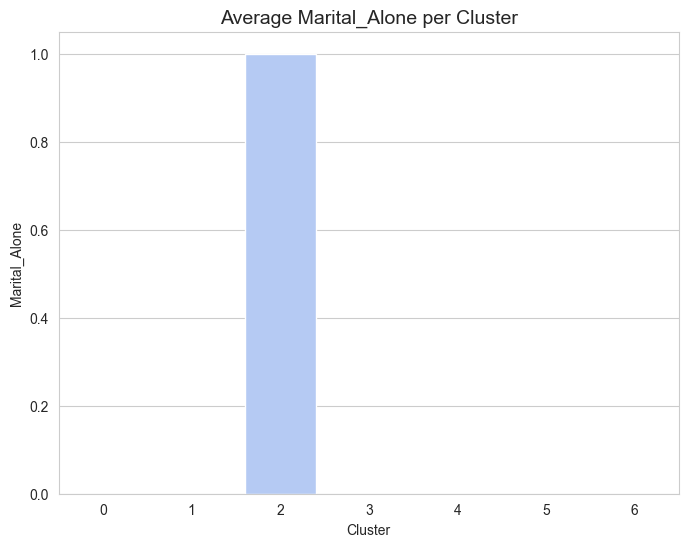

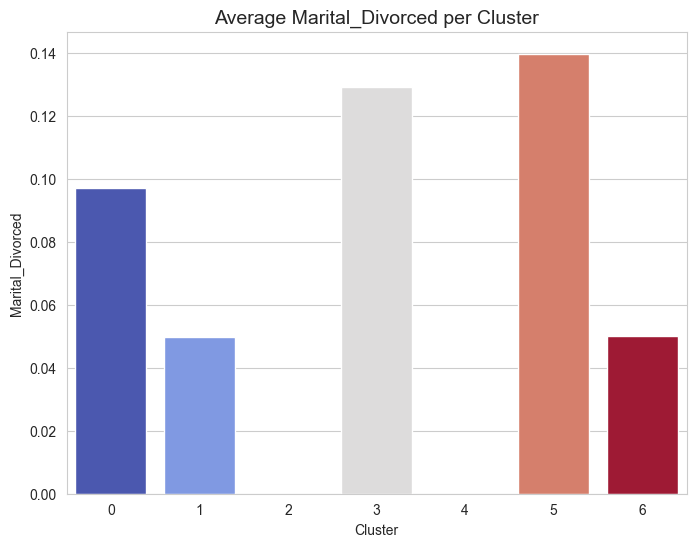

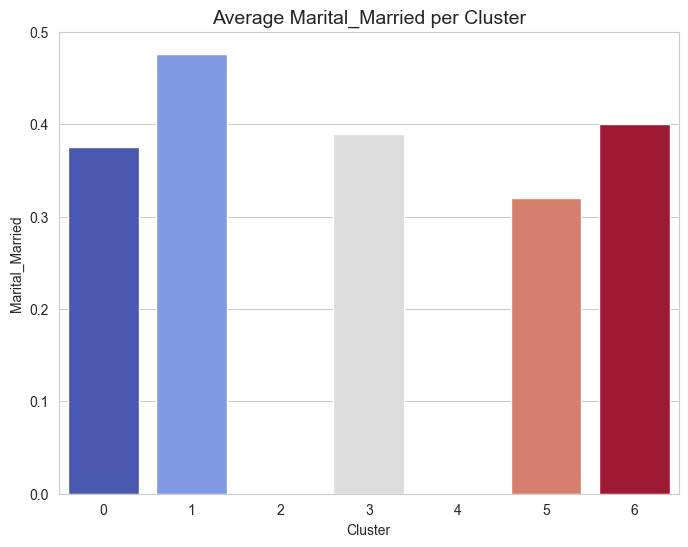

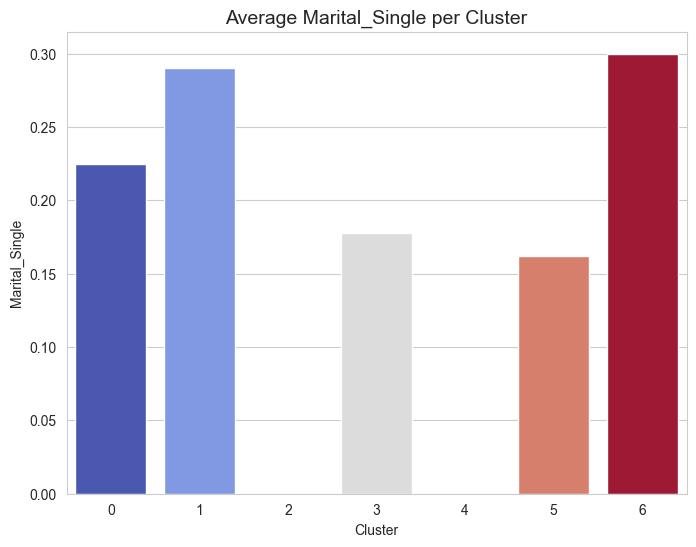

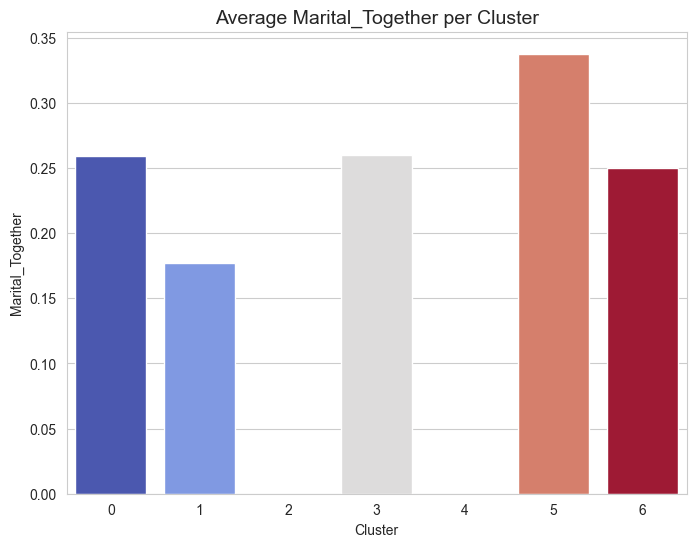

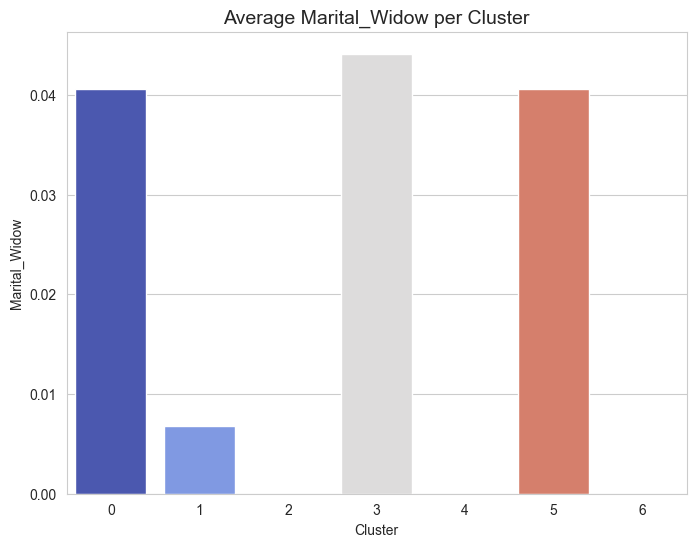

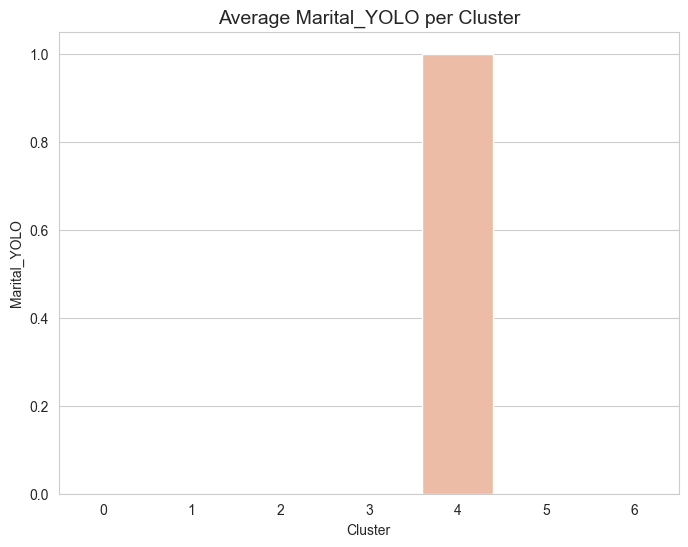

In [108]:
cluster_stats = df.groupby('cluster')[cluster_df.columns].mean().reset_index()

for col in cluster_df.columns:
    plt.figure(figsize=(8, 6))
    sns.barplot(data=cluster_stats, x='cluster', y=col, hue='cluster', palette='coolwarm', legend=False)
    plt.title(f"Average {col} per Cluster", fontsize=14)
    plt.xlabel("Cluster")
    plt.show()

## DBSCAN (Deep Scan)



In [ ]:
# DBSCAN (Deep Scan) - fully standalone section


import base64
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Exact dataset provided with this project, embedded here so there is no path error.
_DATA_B64 = """..."""
dbscan_raw_df = pd.read_csv(
    io.BytesIO(base64.b64decode(_DATA_B64.encode("ascii")))
)

print("Dataset loaded for DBSCAN:", dbscan_raw_df.shape)


dbscan_work = dbscan_raw_df.copy()

drop_cols = ["ID", "Dt_Customer"]
dbscan_work = dbscan_work.drop(
    columns=[c for c in drop_cols if c in dbscan_work.columns],
    errors="ignore"
)

constant_cols = [
    c for c in dbscan_work.columns
    if dbscan_work[c].nunique(dropna=False) <= 1
]
dbscan_work = dbscan_work.drop(columns=constant_cols, errors="ignore")

# Use numeric columns only for distance-based clustering.
dbscan_features = dbscan_work.select_dtypes(include=[np.number]).copy()

# Clean missing/infinite values safely.
dbscan_features = dbscan_features.replace([np.inf, -np.inf], np.nan)
dbscan_features = dbscan_features.fillna(
    dbscan_features.median(numeric_only=True)
)

dbscan_features = dbscan_features.dropna(axis=1, how="all")

# Standardize before DBSCAN.
dbscan_scaler = StandardScaler()
dbscan_scaled = pd.DataFrame(
    dbscan_scaler.fit_transform(dbscan_features),
    columns=dbscan_features.columns,
    index=dbscan_features.index
)


dbscan_pca_model = PCA(n_components=0.90, random_state=42)
X_dbscan = dbscan_pca_model.fit_transform(dbscan_scaled)

print("Numeric features:", dbscan_features.shape[1])
print("DBSCAN/PCA input shape:", X_dbscan.shape)
print(
    "Explained variance retained:",
    round(float(dbscan_pca_model.explained_variance_ratio_.sum()), 4)
)


Dataset loaded for DBSCAN: (1200, 29)
Numeric features: 23
DBSCAN/PCA input shape: (1200, 16)
Explained variance retained: 0.9336


In [ ]:

min_samples_values = [3, 4, 5, 6, 7, 8, 10]
quantiles = np.linspace(0.45, 0.99, 40)

dbscan_results = []

for min_samples in min_samples_values:
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors.fit(X_dbscan)

    distances, _ = neighbors.kneighbors(X_dbscan)
    kth_distances = distances[:, -1]

    eps_values = np.unique(
        np.round(np.quantile(kth_distances, quantiles), 4)
    )

    for eps in eps_values:
        labels = DBSCAN(
            eps=float(eps),
            min_samples=int(min_samples)
        ).fit_predict(X_dbscan)

        non_noise = labels != -1
        labels_non_noise = labels[non_noise]
        n_clusters = len(np.unique(labels_non_noise))
        noise_ratio = float(np.mean(labels == -1))

        sil = np.nan
        dbi = np.nan

        if (
            n_clusters >= 2
            and non_noise.sum() > n_clusters
        ):
            X_non_noise = X_dbscan[non_noise]
            sil = silhouette_score(X_non_noise, labels_non_noise)
            dbi = davies_bouldin_score(X_non_noise, labels_non_noise)

        dbscan_results.append({
            "min_samples": min_samples,
            "eps": float(eps),
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette_score": sil,
            "davies_bouldin_score": dbi
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

valid_results = dbscan_results_df.dropna(
    subset=["silhouette_score", "davies_bouldin_score"]
).copy()

preferred = valid_results[
    valid_results["n_clusters"].between(2, 10)
    & (valid_results["noise_ratio"] <= 0.40)
].copy()

if preferred.empty:
    preferred = valid_results.copy()

if preferred.empty:
    raise RuntimeError(
        "No valid DBSCAN solution was found on the tested parameter range."
    )

best = preferred.sort_values(
    ["silhouette_score", "davies_bouldin_score"],
    ascending=[False, True]
).iloc[0]

best_eps = float(best["eps"])
best_min_samples = int(best["min_samples"])

print(f"Best eps = {best_eps:.4f}")
print(f"Best min_samples = {best_min_samples}")
print(f"Clusters = {int(best['n_clusters'])}")
print(f"Noise ratio = {best['noise_ratio']:.2%}")
print(f"Silhouette Score = {best['silhouette_score']:.4f}")
print(f"Davies-Bouldin Score = {best['davies_bouldin_score']:.4f}")


Best eps = 3.5236
Best min_samples = 6
Clusters = 2
Noise ratio = 12.33%
Silhouette Score = 0.2417
Davies-Bouldin Score = 1.5851


In [7]:
# Train final DBSCAN model.

dbscan_model = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

dbscan_labels = dbscan_model.fit_predict(X_dbscan)

dbscan_output = dbscan_raw_df.copy()
dbscan_output["DBSCAN_Cluster"] = dbscan_labels

n_clusters_final = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_final = int(np.sum(dbscan_labels == -1))

print("Final number of clusters:", n_clusters_final)
print("Noise/outlier points:", n_noise_final)
print("\nCluster counts (-1 = noise):")
print(dbscan_output["DBSCAN_Cluster"].value_counts().sort_index())


Final number of clusters: 2
Noise/outlier points: 148

Cluster counts (-1 = noise):
DBSCAN_Cluster
-1    148
 0    712
 1    340
Name: count, dtype: int64


### Accuracy / Quality Curve


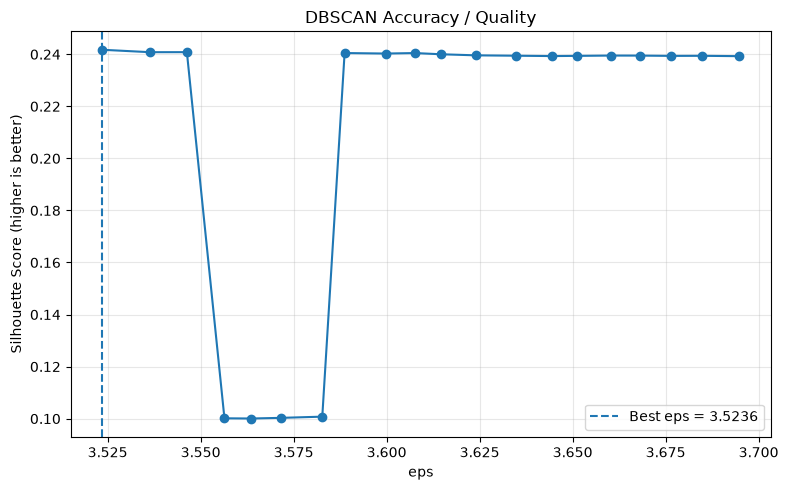

In [ ]:
# Accuracy-like graph:

curve_df = valid_results[
    valid_results["min_samples"] == best_min_samples
].sort_values("eps")

plt.figure(figsize=(8, 5))
plt.plot(
    curve_df["eps"],
    curve_df["silhouette_score"],
    marker="o"
)
plt.axvline(
    best_eps,
    linestyle="--",
    label=f"Best eps = {best_eps:.4f}"
)
plt.title("DBSCAN Accuracy / Quality")
plt.xlabel("eps")
plt.ylabel("Silhouette Score (higher is better)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Loss / Error Curve


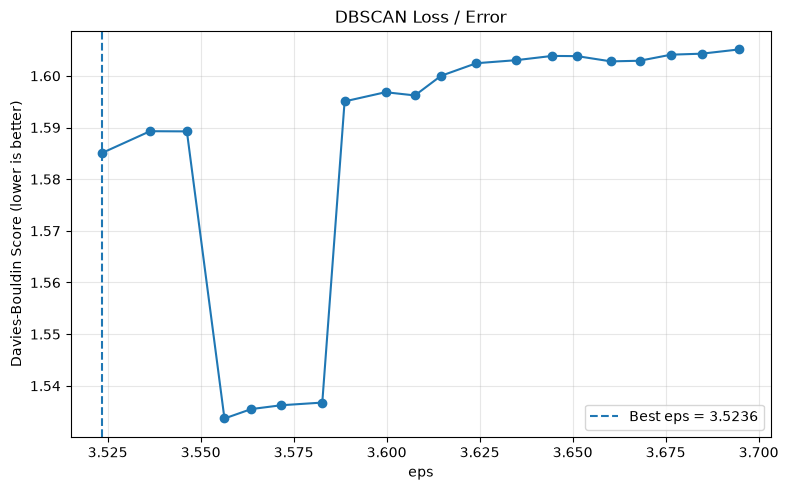

In [ ]:
# Loss-like graph:

plt.figure(figsize=(8, 5))
plt.plot(
    curve_df["eps"],
    curve_df["davies_bouldin_score"],
    marker="o"
)
plt.axvline(
    best_eps,
    linestyle="--",
    label=f"Best eps = {best_eps:.4f}"
)
plt.title("DBSCAN Loss / Error")
plt.xlabel("eps")
plt.ylabel("Davies-Bouldin Score (lower is better)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### DBSCAN Clusters


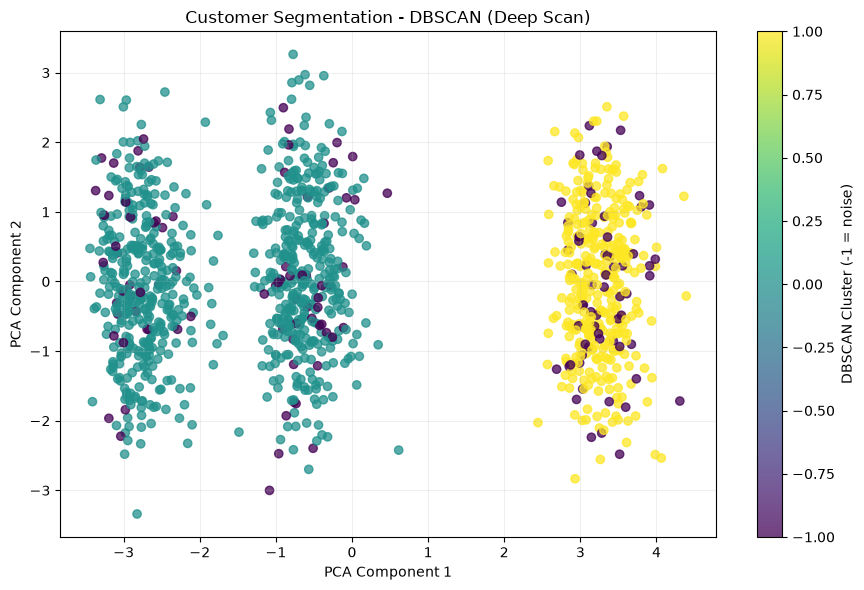

In [10]:
# 2D visualization of DBSCAN clusters.

viz_pca = PCA(n_components=2, random_state=42)
X_viz = viz_pca.fit_transform(dbscan_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_viz[:, 0],
    X_viz[:, 1],
    c=dbscan_labels,
    alpha=0.75
)
plt.title("Customer Segmentation - DBSCAN (Deep Scan)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="DBSCAN Cluster (-1 = noise)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
